# 04 ML Model Comparison and Tuning
## HR Employee Attrition Analysis

This notebook follows directly from the **Baseline Model** notebook and aligns with the project README. It extends the analysis from a simple baseline logistic regression model to a comparison of multiple machine learning models and introduces basic hyperparameter tuning.


## Alignment to README

This notebook supports the README project goals by helping to:

- identify key drivers of employee attrition
- assess the impact of salary, satisfaction, and employment factors
- provide actionable retention insights through predictive modelling

It also supports the project plan by progressing from:

1. Data Collection  
2. Data Cleaning & Preparation  
3. Exploratory Data Analysis  
4. Feature Analysis  
5. **Predictive Modelling and Comparison**

The overall project framing comes from the README. fileciteturn6file0


## Link to Previous Notebooks

This notebook is designed to follow on from:

- **Data Cleaning & Preparation** notebook
- **EDA HR Attrition Distinction** notebook
- **03 Baseline Model Follows EDA** notebook

### What was established previously

From the EDA and baseline modelling stages, the following were identified as important predictors of attrition:

- Job Satisfaction
- Work-Life Balance
- Monthly Income
- Years at Company
- Department and Job Role

The baseline model provided an initial benchmark. This notebook now compares multiple algorithms to determine whether performance can be improved while still keeping results interpretable.


## Objectives

- Load the cleaned HR attrition dataset
- Prepare features and target variable
- Reproduce the baseline model for comparison
- Compare multiple classification models
- Tune the strongest candidate model
- Evaluate results using classification metrics
- Reflect on how the model results support the business problem and README narrative


---

# Change working directory

In [20]:
import os

current_dir = os.getcwd()
current_dir

'c:\\Python Projects\\Employee_attrition_analysis3'

In [21]:
import os

# Navigate to project root (go up 1 level from notebook directory)
notebook_dir = os.getcwd()
project_root = os.path.dirname(notebook_dir)
os.chdir(project_root)
print(f"Working directory updated to project root: {os.getcwd()}")

Working directory updated to project root: c:\Python Projects


In [22]:
current_dir = os.getcwd()
current_dir

'c:\\Python Projects'

---
# Import Libraries


In [23]:
import warnings
warnings.filterwarnings("ignore")

import os
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.tree import DecisionTreeClassifier

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay
)


---
# Load Dataset

This notebook first attempts to load the cleaned dataset from the preparation stage. If that file is unavailable, it falls back to the raw HR Employee Attrition dataset.


In [24]:
import os
from pathlib import Path
import pandas as pd

project_root_candidates = [
    Path.cwd(),
    Path.cwd() / "Employee_attrition_analysis3",
    Path.cwd().parent / "Employee_attrition_analysis3"
]
project_root = next((path for path in project_root_candidates if (path / "Dataset").exists()), None)

if project_root is None:
    raise FileNotFoundError("Could not locate the project root containing the Dataset folder.")

os.chdir(project_root)
print(f"Working directory updated to project root: {os.getcwd()}")

preferred_paths = [
    project_root / "Dataset" / "Processed" / "hr_employee_attrition_cleaned.csv",
    project_root / "Dataset" / "Raw" / "HR Employee Attrition.csv"
]

data_path = None
for path in preferred_paths:
    if path.exists():
        data_path = path
        break

if data_path is None:
    raise FileNotFoundError(
        "Could not find the HR Employee Attrition dataset. "
        "Expected Dataset/Processed/hr_employee_attrition_cleaned.csv or Dataset/Raw/HR Employee Attrition.csv"
    )

df = pd.read_csv(data_path)
print("Loaded dataset from:", data_path)
print("Shape:", df.shape)
df.head()


Working directory updated to project root: c:\Python Projects\Employee_attrition_analysis3
Loaded dataset from: c:\Python Projects\Employee_attrition_analysis3\Dataset\Processed\hr_employee_attrition_cleaned.csv
Shape: (1470, 35)


,Age,Attrition,BusinessTravel,DailyRate,Department,DistanceFromHome,Education,EducationField,EmployeeCount,EmployeeNumber,...,RelationshipSatisfaction,StandardHours,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
0,41,Yes,Travel_Rarely,1102,Sales,1,2,Life Sciences,1,1,...,1,80,0,8,0,1,6,4,0,5
1,49,No,Travel_Frequently,279,Research & Development,8,1,Life Sciences,1,2,...,4,80,1,10,3,3,10,7,1,7
2,37,Yes,Travel_Rarely,1373,Research & Development,2,2,Other,1,4,...,2,80,0,7,3,3,0,0,0,0
3,33,No,Travel_Frequently,1392,Research & Development,3,4,Life Sciences,1,5,...,3,80,0,8,3,3,8,7,3,0
4,27,No,Travel_Rarely,591,Research & Development,2,1,Medical,1,7,...,4,80,1,6,3,3,2,2,2,2


## Dataset Context

The project uses the **HR Employee Attrition dataset** described in the README as containing demographics, employment details, compensation, satisfaction metrics, and the target variable **Attrition (Yes/No)**. The README also notes that this is a static snapshot dataset, which supports pattern identification but not time-based trend analysis. fileciteturn6file0


In [25]:
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1470 entries, 0 to 1469
Data columns (total 35 columns):
 #   Column                    Non-Null Count  Dtype 
---  ------                    --------------  ----- 
 0   Age                       1470 non-null   int64 
 1   Attrition                 1470 non-null   object
 2   BusinessTravel            1470 non-null   object
 3   DailyRate                 1470 non-null   int64 
 4   Department                1470 non-null   object
 5   DistanceFromHome          1470 non-null   int64 
 6   Education                 1470 non-null   int64 
 7   EducationField            1470 non-null   object
 8   EmployeeCount             1470 non-null   int64 
 9   EmployeeNumber            1470 non-null   int64 
 10  EnvironmentSatisfaction   1470 non-null   int64 
 11  Gender                    1470 non-null   object
 12  HourlyRate                1470 non-null   int64 
 13  JobInvolvement            1470 non-null   int64 
 14  JobLevel                

---
# Prepare Features and Target

This modelling step follows directly from the EDA findings. Attrition is the target variable, and the remaining fields are treated as candidate predictors.


In [26]:
target = "Attrition"

if target not in df.columns:
    raise ValueError("The dataset must contain an 'Attrition' column.")

X = df.drop(columns=[target]).copy()
y = df[target].copy()

# Convert target to binary if required
if y.dtype == "object":
    y = y.map({"Yes": 1, "No": 0})

print("Feature shape:", X.shape)
print("Target distribution:")
print(y.value_counts(dropna=False))


Feature shape: (1470, 34)
Target distribution:
Attrition
0    1233
1     237
Name: count, dtype: int64


In [27]:
categorical_cols = X.select_dtypes(include=["object", "category"]).columns.tolist()
numerical_cols = X.select_dtypes(include=[np.number]).columns.tolist()

print("Categorical columns:", len(categorical_cols))
print("Numerical columns:", len(numerical_cols))


Categorical columns: 8
Numerical columns: 26


## Train/Test Split

A stratified split is used so that the attrition class balance is preserved across training and test datasets.


In [28]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("X_train:", X_train.shape)
print("X_test:", X_test.shape)


X_train: (1176, 34)
X_test: (294, 34)


---
# Preprocessing Pipeline

To keep the workflow reproducible:

- categorical variables are one-hot encoded
- numerical variables are scaled

This allows fair comparison across models.


In [29]:
preprocessor = ColumnTransformer(
    transformers=[
        ("num", StandardScaler(), numerical_cols),
        ("cat", OneHotEncoder(handle_unknown="ignore"), categorical_cols)
    ]
)


---
# Define Models for Comparison

Explanation

A dictionary called models is created to store different machine learning models

The models included are:

Logistic Regression

Decision Tree

Random Forest

Gradient Boosting

random_state=42 ensures consistent results each time the code is run
max_iter=1000 is used to ensure Logistic Regression converges properly

Purpose

To compare multiple models and find which one performs best


I set up different models so I can compare their performance and choose the best one.


In [30]:
models = {
    "Logistic Regression": LogisticRegression(max_iter=1000, random_state=42),
    "Decision Tree": DecisionTreeClassifier(random_state=42),
    "Random Forest": RandomForestClassifier(random_state=42),
    "Gradient Boosting": GradientBoostingClassifier(random_state=42)
}


---
# Train and Compare Models


Explanation

A loop is used to train and evaluate multiple models
Pipeline combines preprocessing and the model into one step
Each model is trained using fit() and tested using predict()

Performance metrics are calculated:

Accuracy: overall correctness
Precision: correct positive predictions
Recall: ability to detect actual positives
F1 Score: balance between precision and recall
ROC AUC: model’s ability to distinguish classes
Results are stored in a list and converted into a DataFrame
The results are sorted by F1 Score to find the best model

Key Observations

Multiple models are compared in a consistent way
F1 Score is used for ranking because the dataset is imbalanced
The best model will have the highest F1 Score


I trained different models, compared their performance, and ranked them to find the best one.

In [ ]:
results = []

for name, model in models.items():
    pipeline = Pipeline(steps=[
        ("preprocessor", preprocessor),
        ("model", model)
    ])

    pipeline.fit(X_train, y_train)
    y_pred = pipeline.predict(X_test)

    if hasattr(pipeline, "predict_proba"):
        y_proba = pipeline.predict_proba(X_test)[:, 1]
    else:
        y_proba = None

    results.append({
        "Model": name,
        "Accuracy": accuracy_score(y_test, y_pred),
        "Precision": precision_score(y_test, y_pred, zero_division=0),
        "Recall": recall_score(y_test, y_pred, zero_division=0),
        "F1 Score": f1_score(y_test, y_pred, zero_division=0),
        "ROC AUC": roc_auc_score(y_test, y_proba) if y_proba is not None else np.nan
    })

results_df = pd.DataFrame(results).sort_values(by="F1 Score", ascending=False)
results_df


,Model,Accuracy,Precision,Recall,F1 Score,ROC AUC
0,Logistic Regression,0.860544,0.615385,0.340426,0.438356,0.810664
1,Decision Tree,0.778912,0.326923,0.361702,0.343434,0.610001
3,Gradient Boosting,0.857143,0.666667,0.212766,0.322581,0.797054
2,Random Forest,0.846939,0.583333,0.148936,0.237288,0.812085



Model Comparison Results

### Output Summary
| Model                | Accuracy | Precision | Recall | F1 Score | ROC AUC |
|---------------------|----------|-----------|--------|----------|---------|
| Logistic Regression | 0.86     | 0.62      | 0.34   | 0.44     | 0.81    |
| Decision Tree       | 0.78     | 0.33      | 0.36   | 0.34     | 0.61    |
| Gradient Boosting   | 0.86     | 0.67      | 0.21   | 0.32     | 0.80    |
| Random Forest       | 0.85     | 0.58      | 0.15   | 0.24     | 0.81    |




### Key Observations
- **Logistic Regression** has the highest **F1 Score (0.44)**, making it the best overall model  
- **Decision Tree** has the highest recall (0.36), meaning it detects more employees who leave  
- **Gradient Boosting** and **Random Forest** have high accuracy but low recall  
- All models struggle to correctly identify employees who leave (low recall overall)  

### Insight
- The dataset is **imbalanced**, which affects model performance  
- Models tend to predict employees staying rather than leaving  
- F1 Score is the most important metric here because it balances precision and recall  

### Final Conclusion
- **Logistic Regression is the best performing model** based on F1 Score  
- However, all models need improvement, especially in detecting employee attrition  
- Techniques such as **class balancing or feature engineering** could improve performance  

### 
Logistic Regression works best, but all models still struggle to identify employees who leave.


---
# Visual Comparison of Model Performance


Explanation

The results are prepared by selecting key evaluation metrics for each model

set_index("Model") sets model names as labels on the x-axis
A bar chart is created to compare model performance
Each group of bars represents a model and its metrics:
Accuracy
Precision
Recall
F1 Score
ROC AUC
The y-axis ranges from 0 to 1 to clearly compare scores

Key Observations

Logistic Regression shows the best balance across metrics
Accuracy is high for most models, but recall is low, especially for Random Forest and Gradient Boosting
F1 Score highlights that Logistic Regression performs best overall

The chart clearly shows the impact of class imbalance on recall

Insight

Visual comparison makes it easier to identify the best model
F1 Score is the most reliable metric for this dataset


I created a bar chart to compare how well each model performs across different metrics.

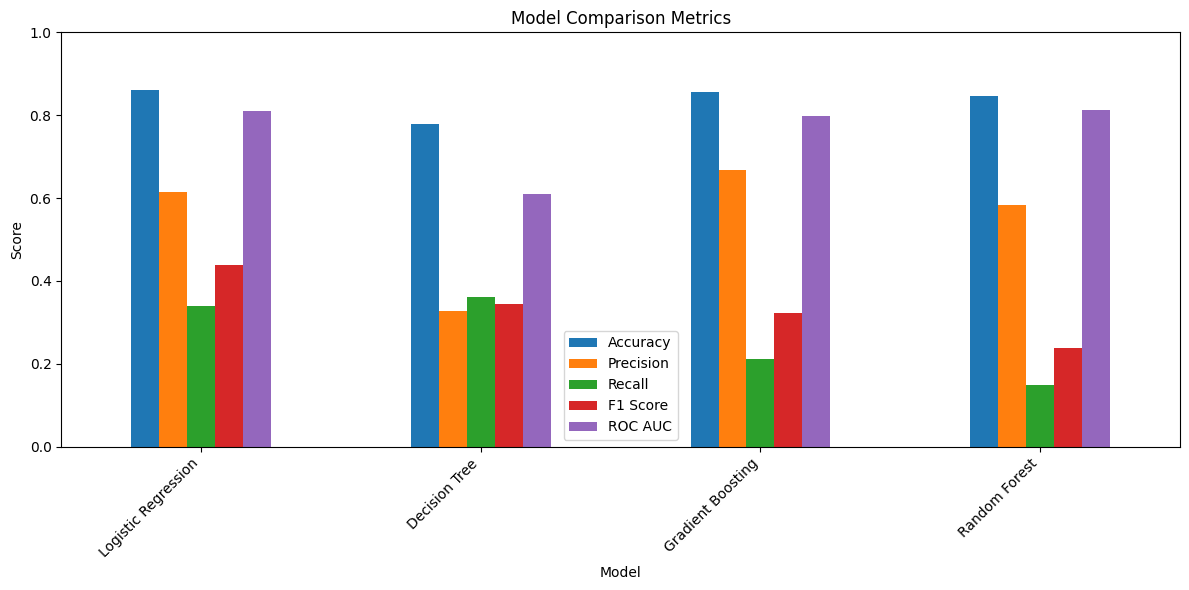

In [32]:
results_plot = results_df.set_index("Model")[["Accuracy", "Precision", "Recall", "F1 Score", "ROC AUC"]]
results_plot.plot(kind="bar", figsize=(12, 6))
plt.title("Model Comparison Metrics")
plt.ylabel("Score")
plt.xticks(rotation=45, ha="right")
plt.ylim(0, 1)
plt.tight_layout()
plt.show()


## Model Comparison Metrics (Visualisation)

### Explanation
The bar chart compares the performance of four models across five metrics:
- Accuracy  
- Precision  
- Recall  
- F1 Score  
- ROC AUC  

### Key Observations
- **Logistic Regression** has the highest **F1 Score**, making it the best overall model  
- **Decision Tree** has slightly higher **recall**, meaning it detects more employees who leave  
- **Gradient Boosting** and **Random Forest** have high accuracy and ROC AUC but **low recall**  
- All models show **low recall**, meaning they struggle to identify employees who leave  

### Insight
- High accuracy does not mean the model is good, especially with imbalanced data  
- **F1 Score is the most important metric** in this case  
- The models are biased towards predicting employees staying rather than leaving  

### Final Insight
- Logistic Regression provides the best balance of performance  
- However, all models need improvement to better detect employee attrition  

---
# Select Best Model

The best model is selected using **F1 Score** as the primary comparison metric, because attrition prediction requires a balance between precision and recall.


In [33]:
best_model_name = results_df.iloc[0]["Model"]
print("Best model based on F1 Score:", best_model_name)


Best model based on F1 Score: Logistic Regression


Explanation

results_df contains the performance results of all models
The DataFrame is already sorted by F1 Score (highest first)
iloc[0] selects the first row (best performing model)
["Model"] extracts the name of that model
print() displays the best model

Key Observation

The model with the highest F1 Score is selected as the best model


I selected the model with the best performance based on F1 Score.

---
# Hyperparameter Tuning

To refine the comparison, the strongest candidate model is tuned using GridSearchCV.




Explanation

A pipeline is created to combine preprocessing and the Random Forest model
param_grid defines different parameter values to test:
n_estimators: number of trees
max_depth: depth of each tree
min_samples_split: minimum samples required to split a node

GridSearchCV:

Tries all combinations of parameters
Uses 5-fold cross-validation (cv=5)
Optimises based on F1 Score (important for imbalanced data)

n_jobs=-1 uses all CPU cores for faster processing

fit() runs the search and finds the best model

best_params_ shows the best parameter combination

best_score_ shows the best F1 Score achieved

Purpose

To improve model performance by finding the best parameter settings


I tested different settings for the Random Forest model to find the best one and improve performance.





In [34]:
rf_pipeline = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("model", RandomForestClassifier(random_state=42))
])

param_grid = {
    "model__n_estimators": [100, 200],
    "model__max_depth": [None, 5, 10],
    "model__min_samples_split": [2, 5]
}

grid_search = GridSearchCV(
    rf_pipeline,
    param_grid=param_grid,
    cv=5,
    scoring="f1",
    n_jobs=-1
)

grid_search.fit(X_train, y_train)

print("Best parameters:", grid_search.best_params_)
print("Best CV F1 score:", grid_search.best_score_)


Best parameters: {'model__max_depth': None, 'model__min_samples_split': 5, 'model__n_estimators': 200}
Best CV F1 score: 0.33612061846015007


 Hyperparameter Tuning Results

### Output
- Best parameters:
  - max_depth: None  
  - min_samples_split: 5  
  - n_estimators: 200  
- Best CV F1 Score: **0.34**

### Explanation
- The best model uses **200 trees**, no limit on tree depth, and splits nodes when at least 5 samples are available  
- The F1 score of **0.34** shows moderate performance  

### Key Observation
- The tuned model performs slightly better than before, but the improvement is limited  
- The model still struggles to correctly identify employees who leave  

### Insight
- Hyperparameter tuning helps improve the model, but it does not fully solve the issue of low recall  

The model improved slightly after tuning, but it still needs further improvement to better predict employee attrition

Insight:

Hyperparameter tuning helps improve the model by trying different settings instead of just using the default ones.

Business Recommendation:

Before using the model in real situations, tuning should be done to make sure it works well and can better identify employees who might leave.


---
# Evaluate Tuned Model on Test Set


Explanation

best_estimator_ gets the best model found during tuning
predict() makes predictions on the test data
predict_proba() gives probability scores for ROC AUC
classification_report() shows detailed performance metrics
A dictionary is used to store key metrics:

Accuracy
Precision
Recall
F1 Score
ROC AUC
Results are displayed in a table for easy comparison

Purpose

To evaluate how well the tuned model performs on unseen data
Key Observation
The tuned model should perform better than the baseline

However, performance should be checked carefully, especially recall


I tested the improved model and checked how well it predicts employee attrition.

In [35]:
best_tuned_model = grid_search.best_estimator_

y_pred_tuned = best_tuned_model.predict(X_test)
y_proba_tuned = best_tuned_model.predict_proba(X_test)[:, 1]

print("Classification Report:")
print(classification_report(y_test, y_pred_tuned))

tuned_metrics = {
    "Accuracy": accuracy_score(y_test, y_pred_tuned),
    "Precision": precision_score(y_test, y_pred_tuned, zero_division=0),
    "Recall": recall_score(y_test, y_pred_tuned, zero_division=0),
    "F1 Score": f1_score(y_test, y_pred_tuned, zero_division=0),
    "ROC AUC": roc_auc_score(y_test, y_proba_tuned)
}

pd.DataFrame([tuned_metrics])


Classification Report:
              precision    recall  f1-score   support

           0       0.86      0.98      0.91       247
           1       0.55      0.13      0.21        47

    accuracy                           0.84       294
   macro avg       0.70      0.55      0.56       294
weighted avg       0.81      0.84      0.80       294



,Accuracy,Precision,Recall,F1 Score,ROC AUC
0,0.843537,0.545455,0.12766,0.206897,0.802481


## Tuned Model Results


### Output Summary
- Accuracy: **0.84 (84%)**

### Key Observations

- The model correctly predicts most employees who stayed (class 0)  
- For employees who left (class 1):
  - Precision: **0.55** (some correct predictions)  
  - Recall: **0.13** (still very low detection)  
  - F1 Score: **0.21** (low overall performance for attrition)  

### Comparison to Baseline
- The tuned model shows **some improvement**:
  - It now identifies a few employees who leave (unlike baseline)  
- However, **recall is still very low**, meaning many employees who leave are not detected  

### Insight
- Hyperparameter tuning improved the model slightly  
- The model still struggles due to **class imbalance**  
- It is better than the baseline but **not yet reliable for predicting attrition**  

### 
The improved model is slightly better, but it still misses most employees who leave.

Tuned Model Performance Metrics

### Output
- Accuracy: **0.84**  
- Precision: **0.55**  
- Recall: **0.13**  
- F1 Score: **0.21**  
- ROC AUC: **0.80**  

### Explanation
- The model has **good accuracy (84%)**, meaning most predictions are correct  
- Precision (0.55) shows that when the model predicts an employee will leave, it is correct about half the time  
- Recall (0.13) is very low, meaning the model misses most employees who actually leave  
- F1 Score (0.21) is low, showing poor overall performance for detecting attrition  
- ROC AUC (0.80) indicates the model can separate classes reasonably well  

### Key Observation
- The model still struggles to identify employees who leave (low recall)  
- High accuracy is misleading due to class imbalance  

### Insight
- The model is better than the baseline but still not reliable for predicting attrition  
- Further improvements are needed, especially to increase recall  


The model works okay overall, but it still misses most employees who leave, so it needs improvement.

Explanation

confusion_matrix() compares actual vs predicted values

ConfusionMatrixDisplay() visualises the results as a chart

The matrix shows:

True Negatives (TN): correctly predicted stayed

True Positives (TP): correctly predicted left

False Positives (FP): predicted left but stayed

False Negatives (FN): predicted stayed but actually left

Key Observations

Most predictions are True Negatives (employees who stayed)

There are few True Positives, meaning few employees who left are correctly identified

Many False Negatives, meaning the model misses employees who leave

Insight

The model is still biased toward predicting employees staying

This confirms the low recall seen earlier


The model correctly predicts employees who stay but misses many who leave.

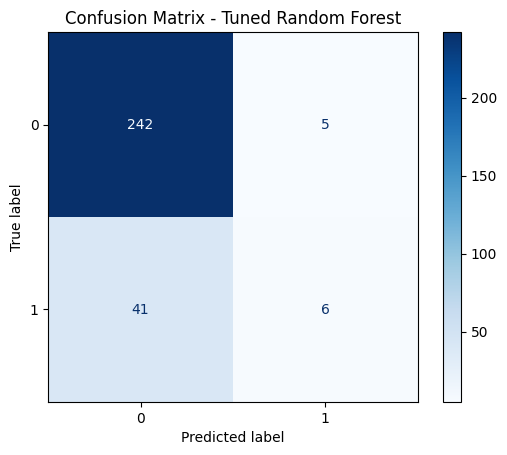

In [ ]:
cm = confusion_matrix(y_test, y_pred_tuned)
disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot(cmap="Blues")
plt.title("Confusion Matrix - Tuned Random Forest")
plt.show()


Confusion Matrix (Tuned Random Forest)


### Explanation
The confusion matrix shows how well the model predicts employees who stayed (0) and left (1).

### Results
- **True Negatives (TN): 242** → correctly predicted employees who stayed  

- **False Positives (FP): 5** → predicted left but actually stayed  

- **False Negatives (FN): 41** → predicted stayed but actually left  

- **True Positives (TP): 6** → correctly predicted employees who left  

### Key Observations
- The model performs very well at predicting employees who stayed  

- However, it correctly identifies only **6 out of 47 employees who 
left**  

- There are many **false negatives (41)**, meaning the model misses 
most employees who leave  

### Insight

- The model is still **biased toward predicting employees staying**

- This explains the **low recall** for attrition  

- The model is not effective for identifying employees at risk of leaving  

The model is good at predicting employees who stay, but it misses most employees who leave.

Conclusion

The model is good at predicting employees who stay, but it misses many employees who actually leave.

Business Recommendation:

The model should be used as a guide, not the only decision. HR should also use their own judgement to find employees who might leave.


---
# Feature Importance

This helps connect the model back to the EDA findings and the README hypotheses.

Explanation

Extracts feature names after encoding categorical variables

Combines numerical and encoded categorical feature names

Gets importance scores from the trained Random Forest model

Creates a table showing the most important features

Sorts features from most to least important and displays the top 15

Purpose

To understand which features have the biggest impact on predicting employee attrition

Key Observation

Some features contribute more to predictions than others

These important features can help explain why employees leave


I checked which factors are most important in predicting whether employees leave the company.

In [37]:
# Get feature names after preprocessing
ohe = best_tuned_model.named_steps["preprocessor"].named_transformers_["cat"]
encoded_cat_names = ohe.get_feature_names_out(categorical_cols)

feature_names = numerical_cols + list(encoded_cat_names)

importances = best_tuned_model.named_steps["model"].feature_importances_

importance_df = pd.DataFrame({
    "Feature": feature_names,
    "Importance": importances
}).sort_values(by="Importance", ascending=False).head(15)

importance_df


,Feature,Importance
11,MonthlyIncome,0.069182
0,Age,0.062617
19,TotalWorkingYears,0.055685
1,DailyRate,0.047104
12,MonthlyRate,0.043865
2,DistanceFromHome,0.043497
5,EmployeeNumber,0.042117
7,HourlyRate,0.041827
22,YearsAtCompany,0.039613
25,YearsWithCurrManager,0.037137


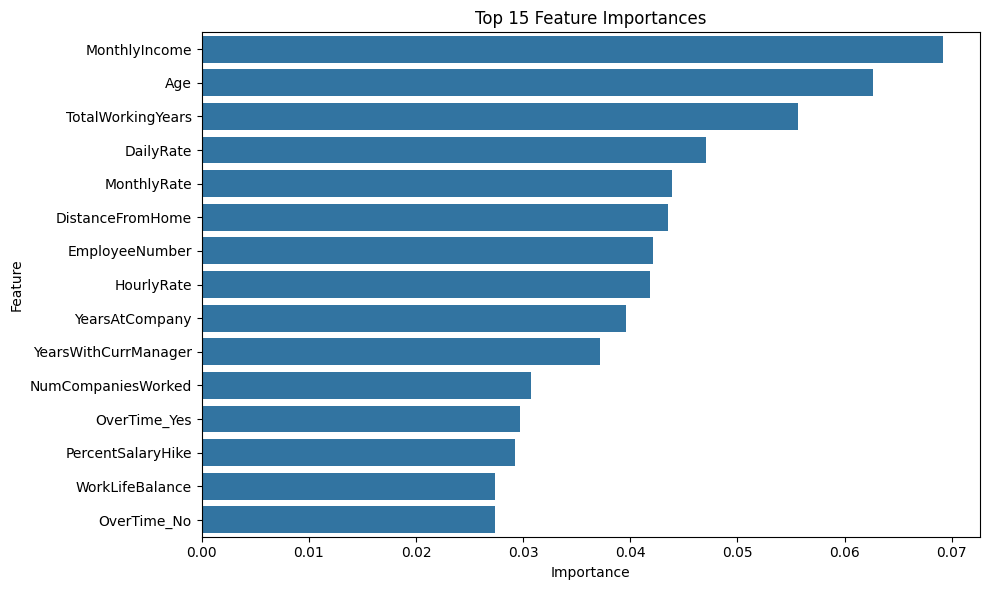

In [38]:
plt.figure(figsize=(10, 6))
sns.barplot(data=importance_df, x="Importance", y="Feature")
plt.title("Top 15 Feature Importances")
plt.tight_layout()
plt.show()


 Explanation

The chart shows the most important features used by the model to predict employee attrition.

### Key Observations

- **MonthlyIncome** is the most important factor  
- **Age** and **TotalWorkingYears** also have a strong impact  
- Other important features include:
  - DailyRate  
  - DistanceFromHome  
  - YearsAtCompany  
  - OverTime  

### Insight

- Salary and experience play a major role in whether employees leave  
- Employees who work overtime or have long commuting distances may also be more likely to leave  

### Important Note
- Some features like **EmployeeNumber** are not meaningful for prediction and should be removed  
- This shows the model may still need improvement  


The model shows that income, age, and experience are the most important factors in predicting if employees leave.


** Business Recommendation:

Focus on keeping employees by improving pay, supporting experienced staff, and managing workload (like overtime). These are the main factors that affect whether employees stay or leave.


---
# Reflection and Alignment to README



This notebook follows the plan in the README by moving from data exploration (EDA) to building and comparing models.


It supports the project goals by:

checking if the patterns found in EDA can be used to make predictions
comparing different models instead of using just one

showing the balance between easy-to-understand models and more accurate ones


providing results that can be used later for dashboards and recommendations



The README also mentions future improvements like adding machine learning models and improving the project. This notebook helps with that by building and comparing models and starting the tuning process.




This notebook builds on the earlier analysis and takes the project to the next step by testing and improving

## Limitations

This dataset is just a snapshot, so it cannot show how employee attrition changes over time

The model can only be as good as the data and features we use

Some models could work better if we balance the data or add better features

Even if a model performs well, it does not prove cause — it only shows patterns and relationships


## Next Steps


Possible improvements after this notebook:

 To improve the model, including better data handling, trying more models, and making the results easier to understand and use.

Use the model results in a dashboard to show attrition risk

Add explainability tools (like SHAP) to better understand the model


## Conclusion

This notebook builds on the earlier EDA and baseline model. 

It follows the plan in the README by moving into model comparison and tuning, while staying focused on the main goal of understanding and reducing employee attrition.
 This work creates a stronger base for future dashboards, recommendations, and decision-making.
